# GATE DA Student Progress Analytics

This notebook is separate from the recommendation-engine notebook.

Use it when you want to:
- insert a specific `STUDENT_ID`
- inspect that student's history
- visualize progress
- estimate future score / accuracy / ELO trends

It reads:
- `profiles`
- `test_history`
- `user_progress`
- `answered_questions`
- `activity_events`

from your Supabase project.

If row-level security blocks the request, paste a valid Supabase access token in the config cell below.
You can also provide email/password and let the notebook fetch a session token automatically.


In [57]:
import json
import subprocess
import uuid
from pathlib import Path
from urllib.parse import urlencode

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from IPython.display import display
from matplotlib.gridspec import GridSpec

ROOT = Path.cwd()
ENV_PATH = ROOT / ".env"
EXPORTER = ROOT / "tools" / "export_question_bank.mjs"
EXPORT_JSON = ROOT / "tmp_question_bank_export.json"


def read_env_file(path: Path) -> dict:
    env = {}
    if not path.exists():
        return env
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        env[key.strip()] = value.strip().strip('"').strip("'")
    return env


ENV = read_env_file(ENV_PATH)
SUPABASE_URL = ENV.get("VITE_STUDENT_SUPABASE_URL")
SUPABASE_KEY = ENV.get("VITE_STUDENT_SUPABASE_PUBLISHABLE_KEY")

if not SUPABASE_URL or not SUPABASE_KEY:
    raise ValueError("Missing Supabase URL or publishable key in .env")


In [58]:
# ============================================================
# 1. CONFIG
# ============================================================

PLACEHOLDER_STUDENT_ID = "paste-student-user-id-here"
# Set this directly if you want to pin a student:
STUDENT_ID = "12efa469-0330-42e1-bc64-82bed3402ae8"
STUDENT_ID = globals().get("STUDENT_ID", None)

# Optional auth:
# 1. Paste a valid Supabase JWT/session token here, OR
# 2. Provide LOGIN_EMAIL and LOGIN_PASSWORD below so the notebook fetches a fresh token automatically.
# Leave SUPABASE_ACCESS_TOKEN as None unless you intentionally want to pin a current token.
SUPABASE_ACCESS_TOKEN = "eyJhbGciOiJFUzI1NiIsImtpZCI6IjA2YTZmZDQ4LWI2MDYtNGMwNS04YzZmLTk2MDFiZWE2MWM1NyIsInR5cCI6IkpXVCJ9.eyJpc3MiOiJodHRwczovL3VraXV4ZWN2eWJ3dm5nd2lyanF0LnN1cGFiYXNlLmNvL2F1dGgvdjEiLCJzdWIiOiJjMzYwNjYxOS01MWM0LTRiZmQtOTIyZS05M2ZkYzEwMWUxY2IiLCJhdWQiOiJhdXRoZW50aWNhdGVkIiwiZXhwIjoxNzc1NzYwOTM0LCJpYXQiOjE3NzU3NTczMzQsImVtYWlsIjoic3VuaWxuYWlra2V0aGF2YXRoQGdtYWlsLmNvbSIsInBob25lIjoiIiwiYXBwX21ldGFkYXRhIjp7InByb3ZpZGVyIjoiZW1haWwiLCJwcm92aWRlcnMiOlsiZW1haWwiXX0sInVzZXJfbWV0YWRhdGEiOnsiZW1haWwiOiJzdW5pbG5haWtrZXRoYXZhdGhAZ21haWwuY29tIiwiZW1haWxfdmVyaWZpZWQiOnRydWUsImZ1bGxfbmFtZSI6IlN1bmlsIiwicGhvbmVfdmVyaWZpZWQiOmZhbHNlLCJyb2xlIjoic3R1ZGVudCIsInN1YiI6ImMzNjA2NjE5LTUxYzQtNGJmZC05MjJlLTkzZmRjMTAxZTFjYiIsInRlYWNoZXJfY29kZSI6IlBXUTk5RjJIIn0sInJvbGUiOiJhdXRoZW50aWNhdGVkIiwiYWFsIjoiYWFsMSIsImFtciI6W3sibWV0aG9kIjoicGFzc3dvcmQiLCJ0aW1lc3RhbXAiOjE3NzU3NTczMzR9XSwic2Vzc2lvbl9pZCI6IjVmYTk4OWU5LWNhNzctNDg2YS1iOTM3LTEyMmRmMWMzOGY3OSIsImlzX2Fub255bW91cyI6ZmFsc2V9.UOBTNe09myD_yyaF9nSNrbYXT1Gr-UEEbpzWkwY6INzMeuEQG4O7UvrhxHZ6pMmiE4_EeQIOQuKBsDy5vYWtdw"
LOGIN_EMAIL = globals().get("LOGIN_EMAIL", None)
LOGIN_PASSWORD = globals().get("LOGIN_PASSWORD", None)


def validate_student_id(student_id: str) -> str:
    student_id = str(student_id).strip()
    if not student_id or student_id == PLACEHOLDER_STUDENT_ID:
        student_id = input("Enter STUDENT_ID (UUID): ").strip()
    if not student_id or student_id == PLACEHOLDER_STUDENT_ID:
        raise ValueError("A valid STUDENT_ID is required to continue.")
    try:
        uuid.UUID(student_id)
    except Exception as exc:
        raise ValueError(f"STUDENT_ID is not a valid UUID: {student_id}") from exc
    return student_id


def fetch_access_token_with_password(email: str, password: str) -> str:
    response = requests.post(
        f"{SUPABASE_URL}/auth/v1/token?grant_type=password",
        headers={
            "apikey": SUPABASE_KEY,
            "Content-Type": "application/json",
        },
        json={"email": email, "password": password},
        timeout=30,
    )
    if not response.ok:
        raise RuntimeError(
            f"Supabase login failed: {response.status_code} {response.text}"
        )
    body = response.json()
    access_token = body.get("access_token")
    if not access_token:
        raise RuntimeError("Supabase login succeeded but no access token was returned.")
    return access_token


def auth_headers(access_token: str | None = None):
    bearer = access_token or SUPABASE_ACCESS_TOKEN or SUPABASE_KEY
    return {
        "apikey": SUPABASE_KEY,
        "Authorization": f"Bearer {bearer}",
        "Accept": "application/json",
    }


def supabase_select(table: str, or_filter: str | None = None, **filters):
    global SUPABASE_ACCESS_TOKEN
    params = {"select": "*"}
    if or_filter:
        params["or"] = or_filter
    for key, value in filters.items():
        params[key] = f"eq.{value}"
    url = f"{SUPABASE_URL}/rest/v1/{table}?{urlencode(params)}"
    response = requests.get(url, headers=auth_headers(), timeout=30)
    if (
        response.status_code == 401
        and "JWT expired" in response.text
        and LOGIN_EMAIL
        and LOGIN_PASSWORD
    ):
        SUPABASE_ACCESS_TOKEN = fetch_access_token_with_password(LOGIN_EMAIL, LOGIN_PASSWORD)
        response = requests.get(url, headers=auth_headers(SUPABASE_ACCESS_TOKEN), timeout=30)
    if not response.ok:
        if response.status_code == 401 and "JWT expired" in response.text:
            raise RuntimeError(
                "Supabase JWT expired. Clear SUPABASE_ACCESS_TOKEN and either paste a fresh token "
                "or set LOGIN_EMAIL and LOGIN_PASSWORD so the notebook can fetch a new session."
            )
        raise RuntimeError(
            f"Supabase query failed for {table}: {response.status_code} {response.text}"
        )
    return response.json()


def safe_supabase_select(table: str, *, allow_missing_table: bool = False, **filters):
    try:
        return supabase_select(table, **filters)
    except RuntimeError as exc:
        message = str(exc)
        if allow_missing_table and (
            "PGRST205" in message
            or "Could not find the table" in message
            or f"for {table}: 404" in message
        ):
            print(
                f"Table '{table}' is not available yet. Skipping it for now. "
                "Apply the latest Supabase migration if you want this data."
            )
            return []
        raise


In [59]:
# ============================================================
# 2. LOAD WEBSITE QUESTION BANK + STUDENT DATA
# ============================================================

STUDENT_ID = validate_student_id(STUDENT_ID)
print("Using STUDENT_ID:", STUDENT_ID)

if not SUPABASE_ACCESS_TOKEN and LOGIN_EMAIL and LOGIN_PASSWORD:
    SUPABASE_ACCESS_TOKEN = fetch_access_token_with_password(LOGIN_EMAIL, LOGIN_PASSWORD)
    print("Authenticated with email/password and obtained a session token.")
elif not SUPABASE_ACCESS_TOKEN:
    print(
        "No explicit session token provided. Queries will use only the publishable key, "
        "which may return empty data because of row-level security."
    )

subprocess.run(
    ["node", str(EXPORTER), str(EXPORT_JSON)],
    check=True,
    cwd=ROOT,
)

question_payload = json.loads(EXPORT_JSON.read_text(encoding="utf-8"))
question_bank = pd.DataFrame(question_payload["questions"])
question_bank["difficulty"] = question_bank["difficulty"].str.lower()

profiles_df = pd.DataFrame(supabase_select("profiles", user_id=STUDENT_ID))
test_history_df = pd.DataFrame(supabase_select("test_history", user_id=STUDENT_ID))
user_progress_df = pd.DataFrame(supabase_select("user_progress", user_id=STUDENT_ID))
answered_df = pd.DataFrame(supabase_select("answered_questions", user_id=STUDENT_ID))
activity_df = pd.DataFrame(
    safe_supabase_select(
        "activity_events",
        allow_missing_table=True,
        or_filter=f"(actor_id.eq.{STUDENT_ID},target_user_id.eq.{STUDENT_ID})",
    )
)

if profiles_df.empty and test_history_df.empty and user_progress_df.empty and answered_df.empty and activity_df.empty:
    print(
        "No visible rows were returned. If this student has activity, the most likely cause is row-level security. "
        "Provide SUPABASE_ACCESS_TOKEN or LOGIN_EMAIL/LOGIN_PASSWORD in the config cell."
    )

if test_history_df.empty:
    print("No test history found for this student yet.")
else:
    test_history_df["completed_at"] = pd.to_datetime(test_history_df["completed_at"])
    test_history_df = test_history_df.sort_values("completed_at").reset_index(drop=True)
    test_history_df["accuracy_pct"] = np.where(
        test_history_df["total_questions"] > 0,
        100 * test_history_df["correct_answers"] / test_history_df["total_questions"],
        np.nan,
    )
    test_history_df["score_pct"] = np.where(
        test_history_df["max_score"] > 0,
        100 * test_history_df["score"] / test_history_df["max_score"],
        np.nan,
    )

if not answered_df.empty:
    answered_df["answered_at"] = pd.to_datetime(answered_df["answered_at"])
    answered_df = answered_df.sort_values("answered_at").reset_index(drop=True)
    answered_enriched_df = answered_df.merge(
        question_bank[["id", "subjectId", "topicId", "difficulty", "eloRating"]],
        left_on="question_id",
        right_on="id",
        how="left",
    )
else:
    answered_enriched_df = answered_df.copy()

if not activity_df.empty:
    activity_df["created_at"] = pd.to_datetime(activity_df["created_at"])
    activity_df = activity_df.sort_values("created_at").reset_index(drop=True)

display(profiles_df)
display(test_history_df.head(10))
display(user_progress_df.head(10))
display(answered_enriched_df.head(10))
display(activity_df.head(20))


Using STUDENT_ID: 12efa469-0330-42e1-bc64-82bed3402ae8
Table 'activity_events' is not available yet. Skipping it for now. Apply the latest Supabase migration if you want this data.


,id,user_id,full_name,avatar_url,elo_rating,streak_count,last_active,study_goal,theme,created_at,updated_at,email,role
0,c047e80e-28aa-44bd-b4ae-0e2f376c14a6,12efa469-0330-42e1-bc64-82bed3402ae8,Sunil,None,1500,0,2026-04-08T21:54:59.023003+00:00,crack_gate,system,2026-04-08T21:54:59.023003+00:00,2026-04-08T21:54:59.023003+00:00,sonunaik1236k@gmail.com,student


,id,user_id,test_type,subject_id,topic_id,score,max_score,questions_attempted,correct_answers,total_questions,violations,duration_seconds,completed_at,accuracy_pct,score_pct
0,d04c912f-21b0-491f-8780-281389dd1ac7,12efa469-0330-42e1-bc64-82bed3402ae8,assignment-test,linear-algebra,la-matrices,6.35,13,10,5,10,0,69,2026-04-08 16:29:59.637000+00:00,50.0,48.846154
1,92ca5703-388f-404d-97d2-6aec5e05de1b,12efa469-0330-42e1-bc64-82bed3402ae8,topic-wise,linear-algebra,la-matrices,5.00,10,10,5,10,0,23,2026-04-08 16:32:39.057000+00:00,50.0,50.000000
2,5362042b-1479-4415-b0ca-003fd1fcb217,12efa469-0330-42e1-bc64-82bed3402ae8,full-mock,None,None,-0.66,98,2,0,64,0,7,2026-04-08 19:39:01.813000+00:00,0.0,-0.673469
3,876081d9-3c3b-40b7-ba6f-c635a2d5c06c,12efa469-0330-42e1-bc64-82bed3402ae8,topic-wise,artificial-intelligence,ai-search,14.00,16,9,8,10,0,300,2026-04-09 06:00:38.798000+00:00,80.0,87.500000
4,8832152c-4891-4ddb-8fcc-e4b884e58ce3,12efa469-0330-42e1-bc64-82bed3402ae8,topic-wise,general-aptitude,ga-verbal-reasoning,2.67,4,4,3,4,0,10,2026-04-09 14:32:20.092000+00:00,75.0,66.750000
5,50ef3d85-616a-447d-8745-60117776fa83,12efa469-0330-42e1-bc64-82bed3402ae8,topic-wise,calculus-optimization,None,5.36,20,10,4,10,0,41,2026-04-09 17:46:41.406000+00:00,40.0,26.800000


""


""


""


In [60]:
# ============================================================
# 3. STUDENT PROGRESS METRICS + FUTURE PREDICTIONS
# ============================================================

profile = profiles_df.iloc[0].to_dict() if not profiles_df.empty else {}
current_elo = int(profile.get("elo_rating", 1500))

if not user_progress_df.empty:
    user_progress_df["accuracy_pct"] = np.where(
        user_progress_df["total"] > 0,
        100 * user_progress_df["correct"] / user_progress_df["total"],
        np.nan,
    )

if not answered_enriched_df.empty:
    topic_accuracy_df = (
        answered_enriched_df.groupby(["subjectId", "topicId"], dropna=False)["was_correct"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={"count": "attempts", "mean": "accuracy"})
    )
    topic_accuracy_df["accuracy_pct"] = 100 * topic_accuracy_df["accuracy"]
else:
    topic_accuracy_df = pd.DataFrame(columns=["subjectId", "topicId", "attempts", "accuracy", "accuracy_pct"])

activity_breakdown_df = (
    activity_df.groupby("event_type").size().reset_index(name="count").sort_values("count", ascending=False)
    if not activity_df.empty
    else pd.DataFrame(columns=["event_type", "count"])
)

active_days = (
    int(activity_df["created_at"].dt.date.nunique())
    if not activity_df.empty
    else 0
)


def linear_forecast(series: pd.Series, steps: int = 3):
    series = series.dropna().reset_index(drop=True)
    if len(series) < 2:
        base = float(series.iloc[-1]) if len(series) == 1 else np.nan
        return [base for _ in range(steps)]
    x = np.arange(len(series))
    y = series.to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    preds = [intercept + slope * (len(series) + i) for i in range(steps)]
    return preds


if not test_history_df.empty:
    next_score_pct_predictions = [max(0, min(100, value)) for value in linear_forecast(test_history_df["score_pct"], steps=3)]
    next_accuracy_pct_predictions = [max(0, min(100, value)) for value in linear_forecast(test_history_df["accuracy_pct"], steps=3)]
else:
    next_score_pct_predictions = [np.nan, np.nan, np.nan]
    next_accuracy_pct_predictions = [np.nan, np.nan, np.nan]

subject_strength_df = (
    user_progress_df.sort_values("accuracy_pct", ascending=False)
    if not user_progress_df.empty
    else pd.DataFrame(columns=["subject_id", "accuracy_pct", "total"])
)

weak_topics_df = (
    topic_accuracy_df[topic_accuracy_df["attempts"] >= 2]
    .sort_values(["accuracy_pct", "attempts"], ascending=[True, False])
    if not topic_accuracy_df.empty
    else pd.DataFrame(columns=["subjectId", "topicId", "attempts", "accuracy_pct"])
)

readiness_score = np.nan
if not test_history_df.empty and not user_progress_df.empty:
    readiness_score = round(
        0.55 * float(test_history_df["score_pct"].tail(5).mean()) +
        0.45 * float(user_progress_df["accuracy_pct"].mean()),
        2,
    )

predicted_next_elo = current_elo
if not np.isnan(next_accuracy_pct_predictions[0]):
    elo_shift = (next_accuracy_pct_predictions[0] - 60) * 2.2
    predicted_next_elo = int(round(current_elo + elo_shift))

summary_df = pd.DataFrame(
    [
        {"metric": "Current ELO", "value": current_elo},
        {"metric": "Predicted next ELO", "value": predicted_next_elo},
        {"metric": "Readiness score", "value": readiness_score},
        {"metric": "Tests taken", "value": len(test_history_df)},
        {"metric": "Questions answered", "value": len(answered_enriched_df)},
        {"metric": "Activity events", "value": len(activity_df)},
        {"metric": "Active days", "value": active_days},
    ]
)

display(summary_df)
display(subject_strength_df.head(10))
display(weak_topics_df.head(12))
display(activity_breakdown_df.head(12))

prediction_df = pd.DataFrame(
    {
        "future_test_number": [1, 2, 3],
        "predicted_score_pct": next_score_pct_predictions,
        "predicted_accuracy_pct": next_accuracy_pct_predictions,
    }
)
display(prediction_df)


,metric,value
0,Current ELO,1500.0
1,Predicted next ELO,1499.0
2,Readiness score,NaN
3,Tests taken,6.0
4,Questions answered,0.0
5,Activity events,0.0
6,Active days,0.0


,subject_id,accuracy_pct,total


,subjectId,topicId,attempts,accuracy_pct


,event_type,count


,future_test_number,predicted_score_pct,predicted_accuracy_pct
0,1,49.356384,59.666667
1,2,50.161890,62.666667
2,3,50.967396,65.666667


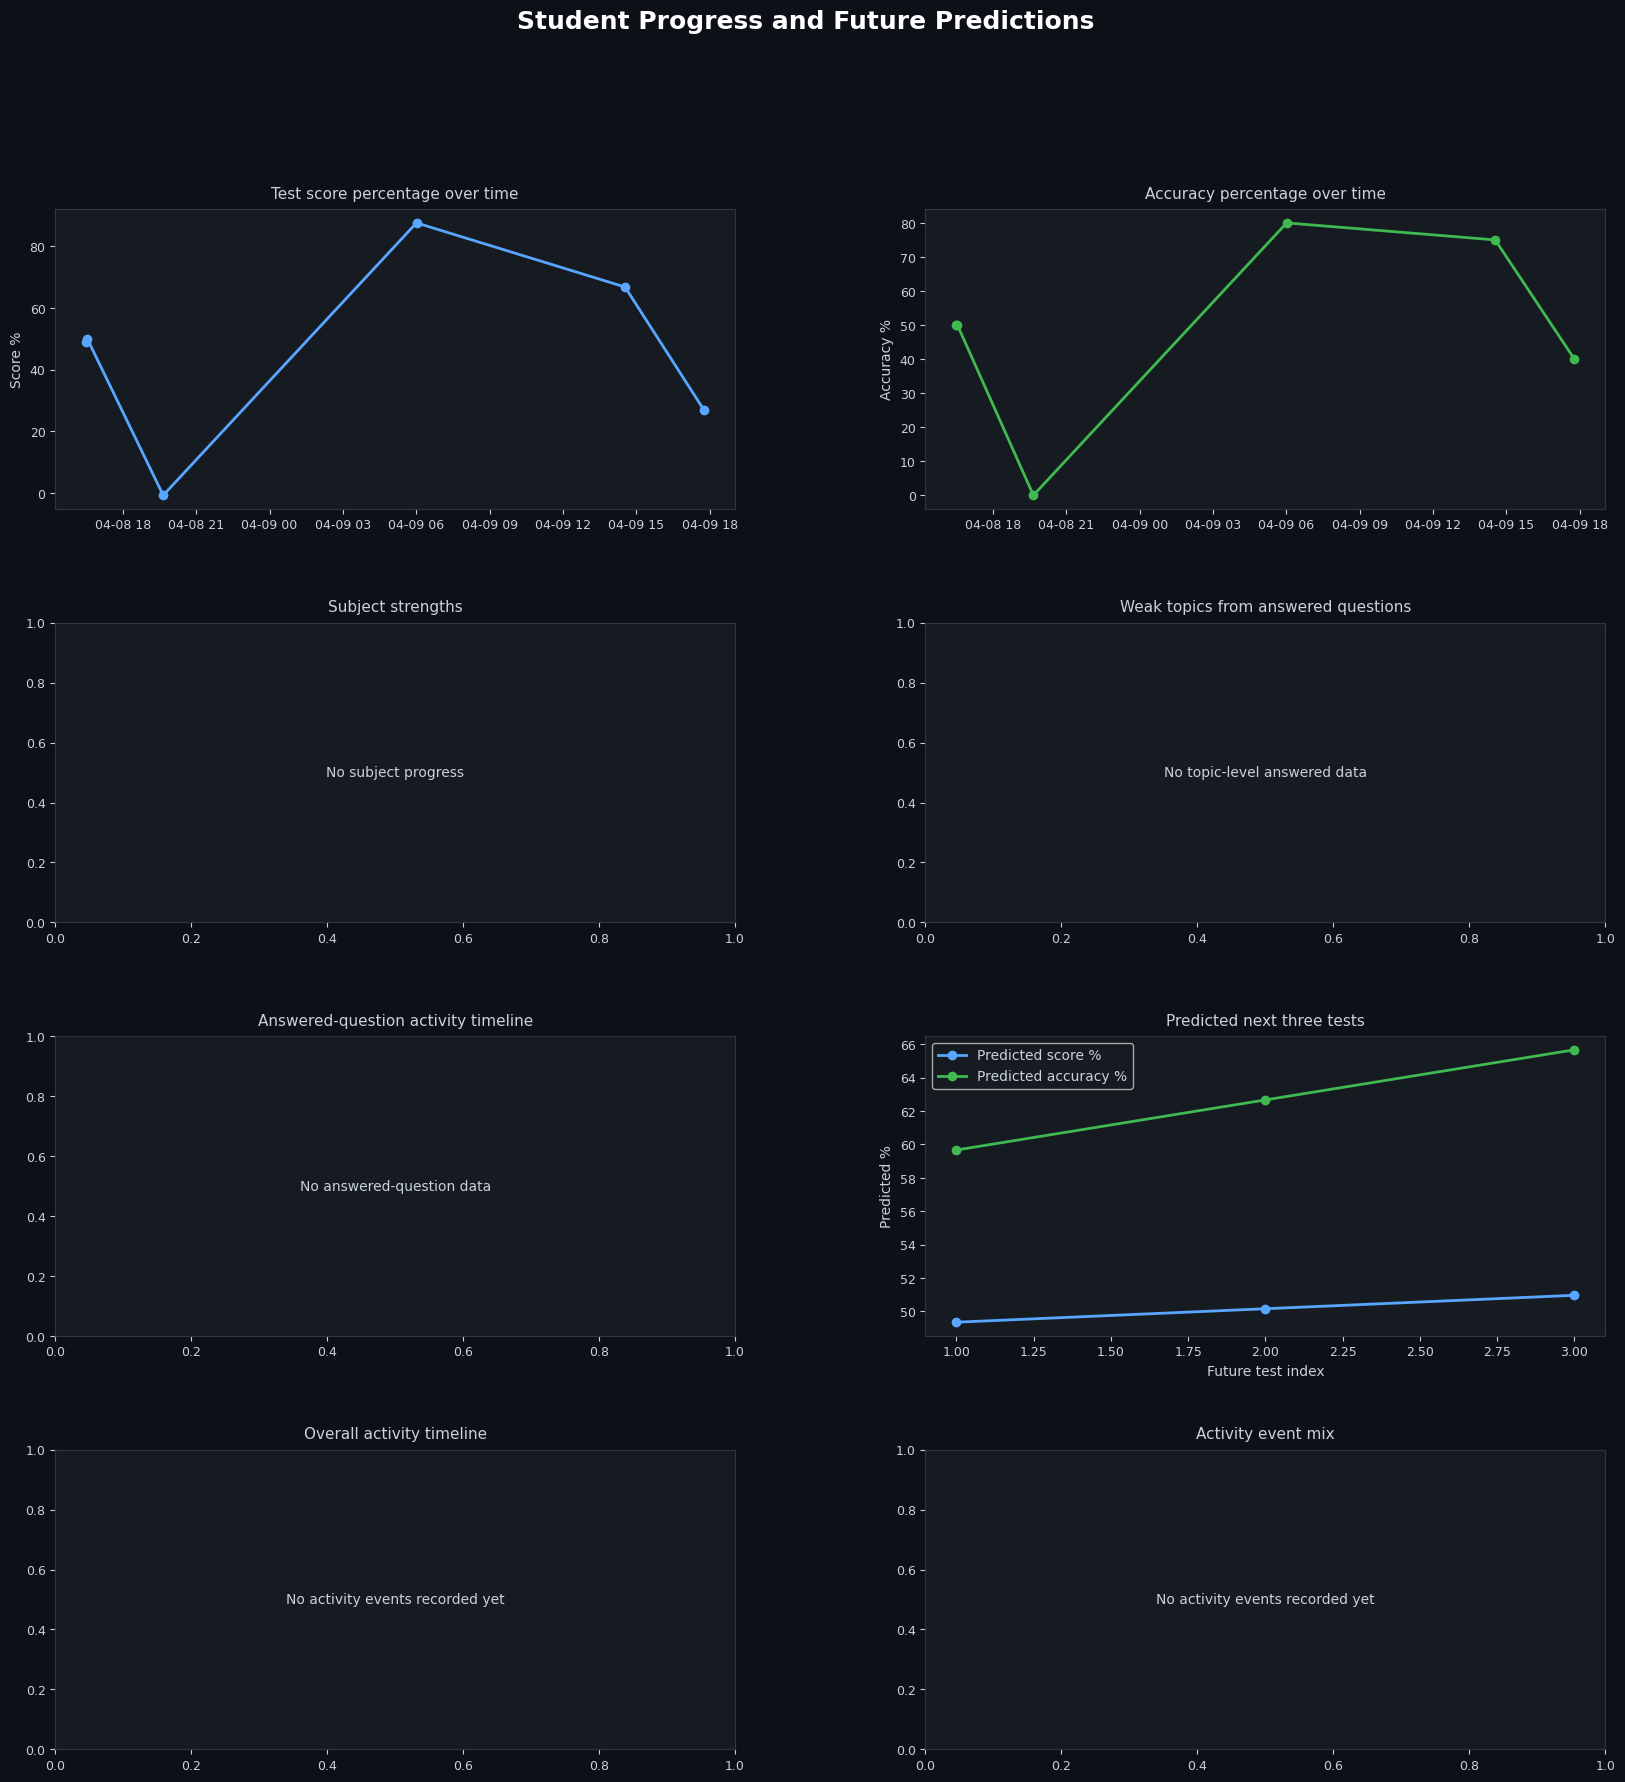

In [61]:
# ============================================================
# 4. PROGRESS + PREDICTION PLOTS
# ============================================================

fig = plt.figure(figsize=(20, 20), facecolor="#0d1117")
fig.suptitle("Student Progress and Future Predictions", color="white", fontsize=18, fontweight="bold")
gs = GridSpec(4, 2, figure=fig, hspace=0.38, wspace=0.28)
panel = "#161b22"
text_c = "#c9d1d9"


def style_ax(ax, title):
    ax.set_facecolor(panel)
    ax.set_title(title, color=text_c, fontsize=11, pad=8)
    ax.tick_params(colors=text_c, labelsize=9)
    ax.xaxis.label.set_color(text_c)
    ax.yaxis.label.set_color(text_c)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")


ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, "Test score percentage over time")
if not test_history_df.empty:
    ax1.plot(test_history_df["completed_at"], test_history_df["score_pct"], color="#58a6ff", lw=2, marker="o")
    ax1.set_ylabel("Score %")
else:
    ax1.text(0.5, 0.5, "No test history", color=text_c, ha="center", va="center")

ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, "Accuracy percentage over time")
if not test_history_df.empty:
    ax2.plot(test_history_df["completed_at"], test_history_df["accuracy_pct"], color="#3fb950", lw=2, marker="o")
    ax2.set_ylabel("Accuracy %")
else:
    ax2.text(0.5, 0.5, "No test history", color=text_c, ha="center", va="center")

ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3, "Subject strengths")
if not subject_strength_df.empty:
    top_subjects = subject_strength_df.head(10)
    ax3.barh(top_subjects["subject_id"][::-1], top_subjects["accuracy_pct"][::-1], color="#d2a8ff")
    ax3.set_xlabel("Accuracy %")
else:
    ax3.text(0.5, 0.5, "No subject progress", color=text_c, ha="center", va="center")

ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4, "Weak topics from answered questions")
if not weak_topics_df.empty:
    top_weak = weak_topics_df.head(12)
    labels = (top_weak["subjectId"].fillna("unknown") + " / " + top_weak["topicId"].fillna("unknown")).tolist()
    ax4.barh(labels[::-1], top_weak["accuracy_pct"].tolist()[::-1], color="#ff7b72")
    ax4.set_xlabel("Accuracy %")
else:
    ax4.text(0.5, 0.5, "No topic-level answered data", color=text_c, ha="center", va="center")

ax5 = fig.add_subplot(gs[2, 0])
style_ax(ax5, "Answered-question activity timeline")
if not answered_enriched_df.empty:
    daily_activity = answered_enriched_df.groupby(answered_enriched_df["answered_at"].dt.date)["question_id"].count()
    ax5.plot(pd.to_datetime(daily_activity.index), daily_activity.values, color="#ffa657", lw=2)
    ax5.set_ylabel("Questions answered")
else:
    ax5.text(0.5, 0.5, "No answered-question data", color=text_c, ha="center", va="center")

ax6 = fig.add_subplot(gs[2, 1])
style_ax(ax6, "Predicted next three tests")
if prediction_df["predicted_score_pct"].notna().any():
    ax6.plot(prediction_df["future_test_number"], prediction_df["predicted_score_pct"], color="#58a6ff", lw=2, marker="o", label="Predicted score %")
    ax6.plot(prediction_df["future_test_number"], prediction_df["predicted_accuracy_pct"], color="#3fb950", lw=2, marker="o", label="Predicted accuracy %")
    ax6.set_xlabel("Future test index")
    ax6.set_ylabel("Predicted %")
    ax6.legend(facecolor=panel, labelcolor=text_c)
else:
    ax6.text(0.5, 0.5, "Not enough test data for prediction", color=text_c, ha="center", va="center")

ax7 = fig.add_subplot(gs[3, 0])
style_ax(ax7, "Overall activity timeline")
if not activity_df.empty:
    daily_events = activity_df.groupby(activity_df["created_at"].dt.date)["event_type"].count()
    ax7.plot(pd.to_datetime(daily_events.index), daily_events.values, color="#79c0ff", lw=2, marker="o")
    ax7.set_ylabel("Events")
else:
    ax7.text(0.5, 0.5, "No activity events recorded yet", color=text_c, ha="center", va="center")

ax8 = fig.add_subplot(gs[3, 1])
style_ax(ax8, "Activity event mix")
if not activity_breakdown_df.empty:
    top_events = activity_breakdown_df.head(10)
    ax8.barh(top_events["event_type"][::-1], top_events["count"][::-1], color="#f2cc60")
    ax8.set_xlabel("Event count")
else:
    ax8.text(0.5, 0.5, "No activity events recorded yet", color=text_c, ha="center", va="center")

plt.show()
